<a href="https://colab.research.google.com/github/kittanaiwisetkhro/BSC_DPDM2025/blob/main/Ch5_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Dataset

In [ ]:
# load mnis dataset from sklearn

In [1]:
# from sklearn.datasets import fetch_openml

# # Load data from https://www.openml.org/d/554
# X, y = fetch_openml('mnist_784', version=1, return_X_y=True, as_frame=False)

In [3]:
# print(f"Shape of X: {X.shape}")
# print(f"Shape of y: {y.shape}")
# print(f"First 5 labels: {y[:5]}")

Shape of X: (70000, 784)
Shape of y: (70000,)
First 5 labels: ['5' '0' '4' '1' '9']


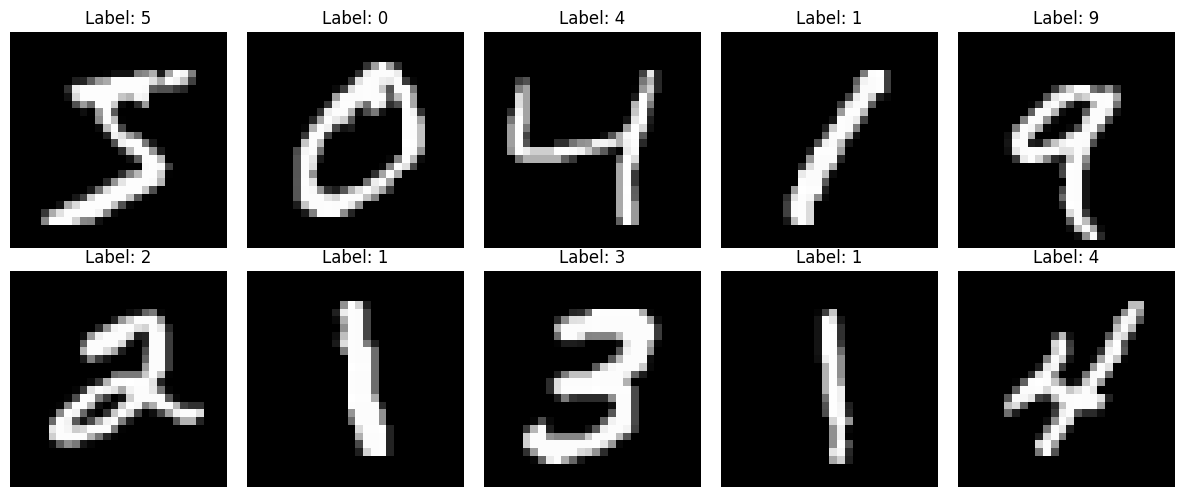

In [4]:
# import matplotlib.pyplot as plt

# # Display the first 10 images from the dataset
# fig, axes = plt.subplots(2, 5, figsize=(12, 5))
# for i, ax in enumerate(axes.flat):
#     ax.imshow(X[i].reshape(28, 28), cmap='gray')
#     ax.set_title(f"Label: {y[i]}")
#     ax.axis('off')
# plt.tight_layout()
# plt.show()

In [7]:
from sklearn.datasets import load_digits

# Load the digits dataset (a modified MNIST dataset)
digits = load_digits()
X, y = digits.data, digits.target

print(f"Shape of data: {X.shape}")
print(f"Shape of target: {y.shape}")
print(f"Number of classes: {len(digits.target_names)}")
print(f"First 5 target labels: {y[:5]}")

Shape of data: (1797, 64)
Shape of target: (1797,)
Number of classes: 10
First 5 target labels: [0 1 2 3 4]


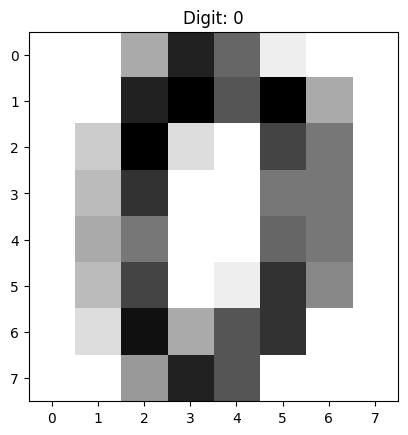

In [9]:
import matplotlib.pyplot as plt

# Get the first image and its target label
first_image = X[0]
first_label = y[0]

# Reshape the 64-feature vector to an 8x8 image
image_reshaped = first_image.reshape(8, 8)

# Display the image
plt.imshow(image_reshaped, cmap=plt.cm.gray_r, interpolation='nearest')
plt.title(f"Digit: {first_label}")
plt.show()

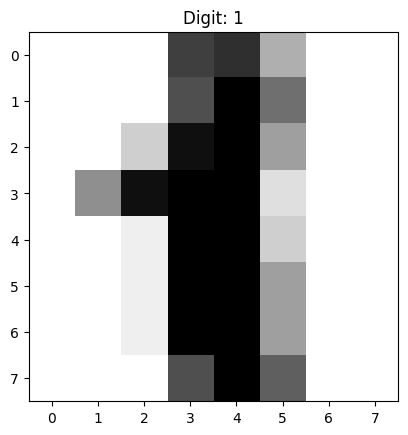

In [27]:
import matplotlib.pyplot as plt

# Get the first image and its target label
first_image = X[1]
first_label = y[1]

# Reshape the 64-feature vector to an 8x8 image
image_reshaped = first_image.reshape(8, 8)

# Display the image
plt.imshow(image_reshaped, cmap=plt.cm.gray_r, interpolation='nearest')
plt.title(f"Digit: {first_label}")
plt.show()

In [21]:
digits.data

array([[ 0.,  0.,  5., ...,  0.,  0.,  0.],
       [ 0.,  0.,  0., ..., 10.,  0.,  0.],
       [ 0.,  0.,  0., ..., 16.,  9.,  0.],
       ...,
       [ 0.,  0.,  1., ...,  6.,  0.,  0.],
       [ 0.,  0.,  2., ..., 12.,  0.,  0.],
       [ 0.,  0., 10., ..., 12.,  1.,  0.]])

In [29]:
import pandas as pd

# Create a DataFrame for the features (pixel data)
df = pd.DataFrame(digits.data)

# Add the target (digit label) as a new column
df['target'] = digits.target

print("DataFrame created successfully with shape:", df.shape)

DataFrame created successfully with shape: (1797, 65)


In [30]:
df.head()

,0,1,2,3,4,5,6,7,8,9,...,55,56,57,58,59,60,61,62,63,target
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0,0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0,1
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0,2
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0,3
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0,4


# Model Construction

1. import
2. defind (hyper-parameters)
3. train (fitting)
4. evaluate




In [31]:
X.shape

(1797, 64)

In [34]:
# แบ่งข้อมูลโดยให้ Training set อยู่ที่ 1700 ตัวแรก
X_train = X[:1700]
y_train = y[:1700]

# ให้ Testing set อยู่ที่ส่วนที่เหลือของข้อมูล (ข้อมูลที่ไม่เคยเห็น)
X_test = X[1700:]
y_test = y[1700:]

In [ ]:
# sklearn decision tree Classifier

## 1. import

In [35]:
from sklearn.tree import DecisionTreeClassifier

## 2. defind

In [36]:
tree0 = DecisionTreeClassifier()

In [50]:
tree0 = DecisionTreeClassifier(random_state=6)

## 3. train

In [51]:
tree0.fit(X_train,y_train)

DecisionTreeClassifier(random_state=6)

In [ ]:
# draw a trained tree

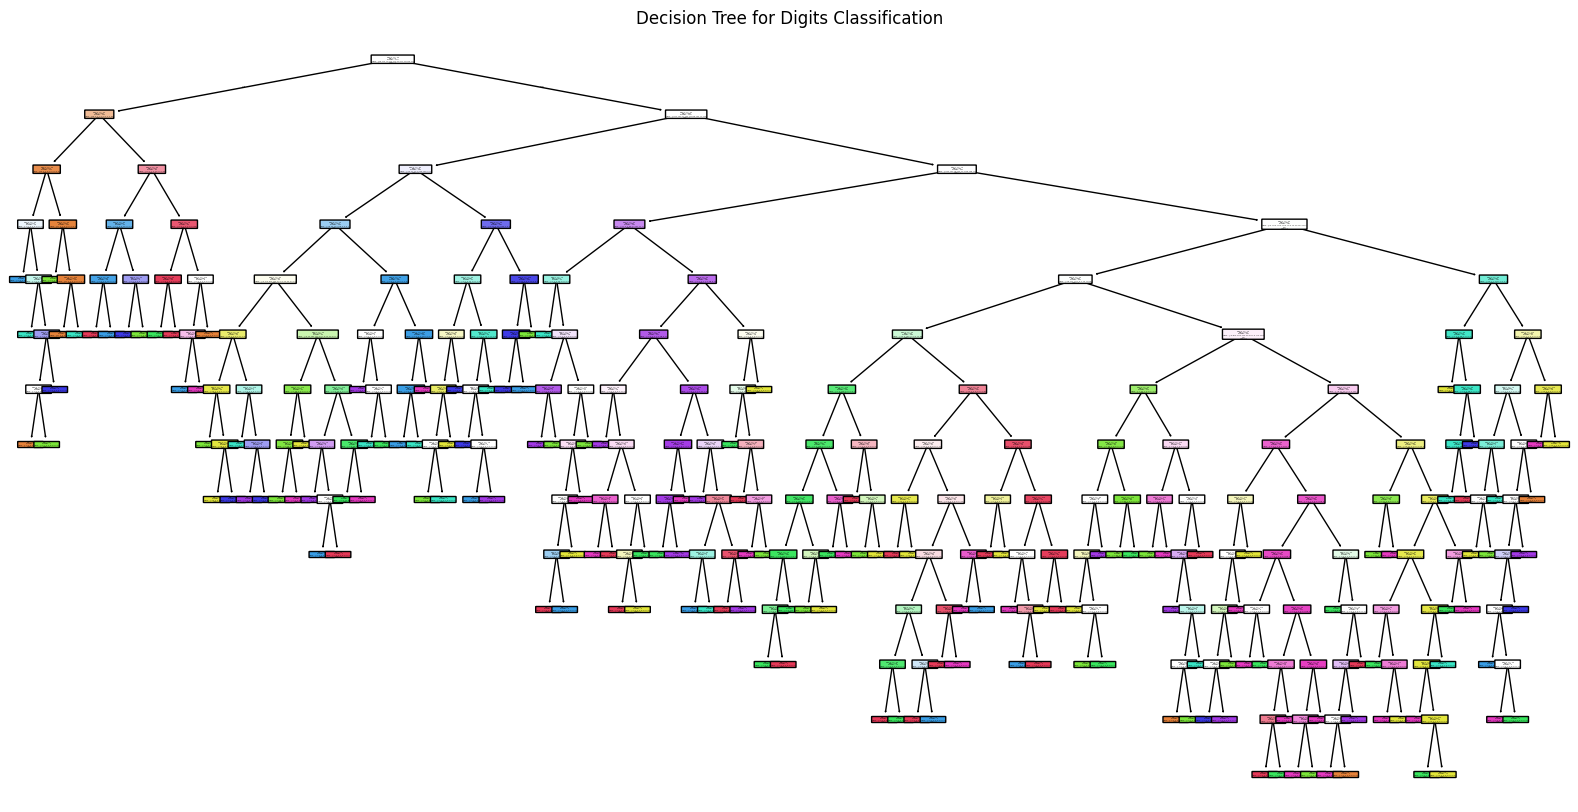

In [52]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 10)) # Adjust figure size for better visualization
plot_tree(tree0, filled=True, feature_names=digits.feature_names, class_names=[str(i) for i in digits.target_names], rounded=True);
plt.title("Decision Tree for Digits Classification")
plt.show()

## 4. evaluate

In [53]:
y_predict = tree0.predict(X_test)

In [54]:
y_predict

array([8, 6, 5, 0, 9, 8, 9, 8, 4, 1, 7, 7, 9, 5, 1, 0, 0, 6, 2, 7, 8, 2,
       0, 3, 8, 6, 8, 8, 7, 4, 3, 4, 6, 6, 6, 4, 9, 1, 9, 0, 9, 6, 7, 8,
       2, 0, 0, 6, 7, 6, 8, 2, 1, 7, 4, 6, 3, 1, 2, 9, 1, 7, 6, 8, 4, 8,
       1, 4, 0, 5, 5, 6, 9, 6, 1, 7, 5, 4, 4, 7, 2, 5, 2, 2, 5, 7, 9, 4,
       4, 3, 3, 4, 9, 0, 8, 9, 8])

In [55]:
y_tast

array([0, 1, 2, ..., 0, 9, 5])

In [ ]:
# evaluate with accuracy

In [56]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_predict)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.7938


## Pre-pruning ((hyper-parameters tuning)

In [57]:
from sklearn.tree import DecisionTreeClassifier
tree1 = DecisionTreeClassifier(random_state=6, max_depth=3)
tree1.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3, random_state=6)

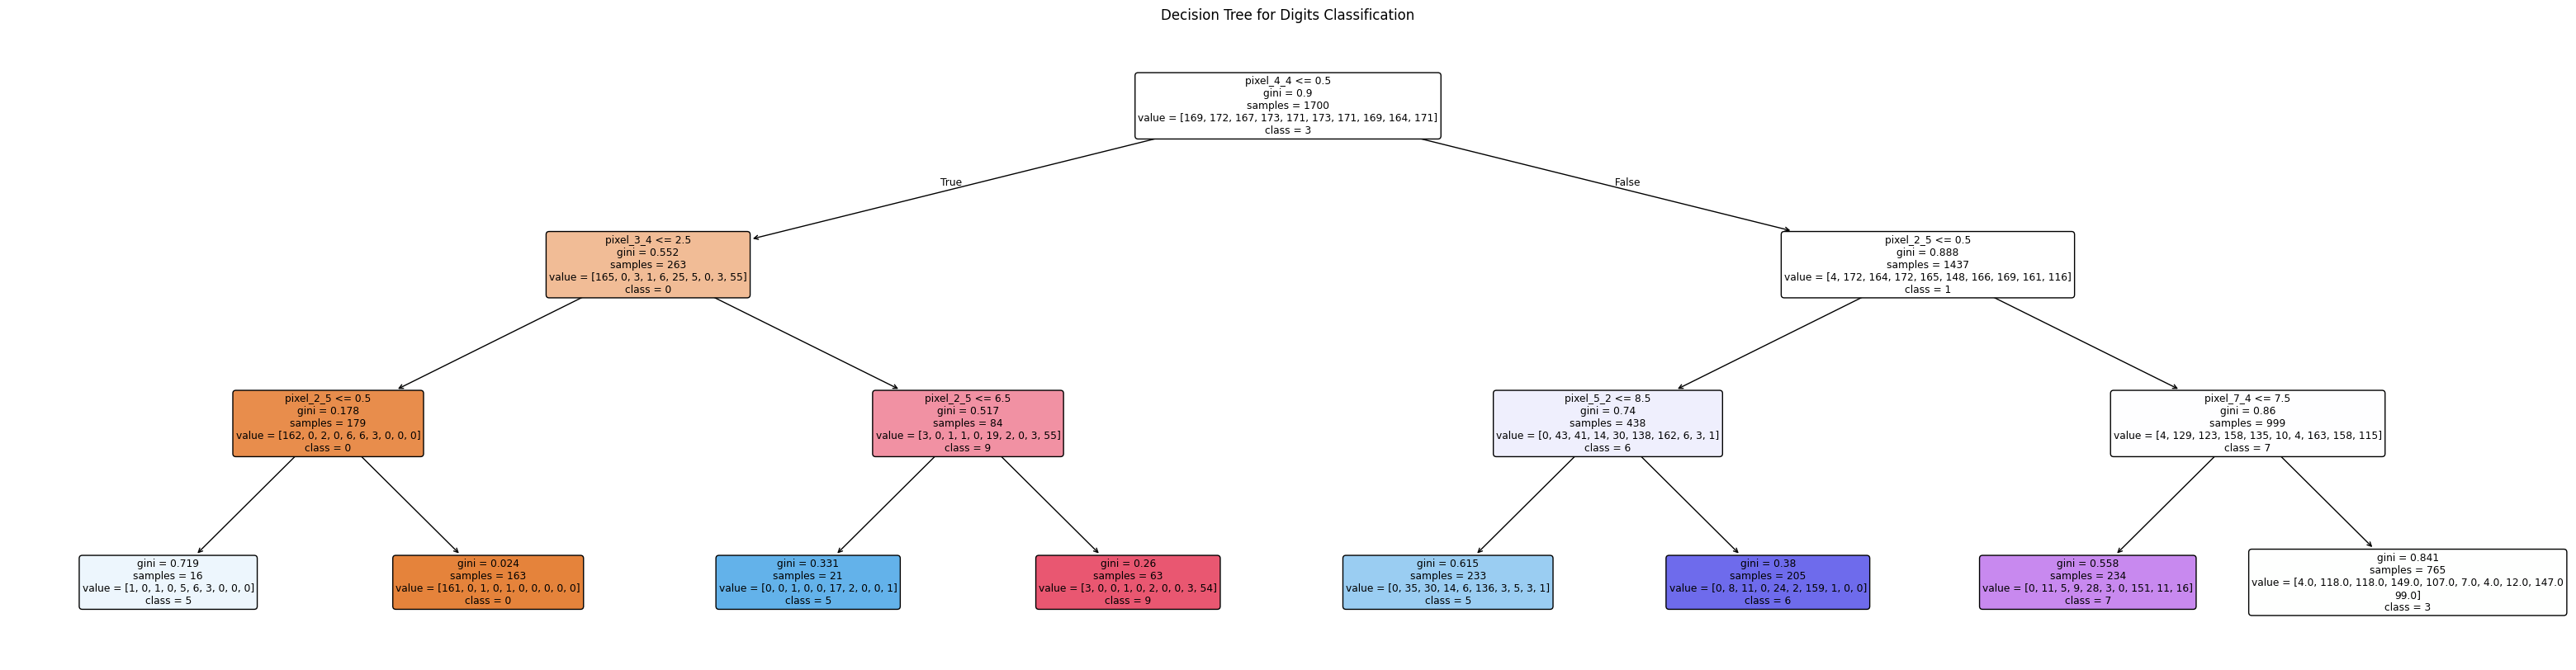

In [67]:
from numpy import random
plt.figure(figsize=(40, 10))
plot_tree(tree1, filled=True, rounded=True, feature_names=digits.feature_names, class_names=[str(i) for i in digits.target_names]);
plt.title("Decision Tree for Digits Classification")
plt.show()

### 4.1 evaluate

In [69]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_predict)
print(f"Accuracy: {accuracy:.4f}")

In [70]:
from sklearn.tree import DecisionTreeClassifier
tree2 = DecisionTreeClassifier(random_state=6, max_depth=7)
tree2.fit(X_train, y_train)
y_predict2 = tree2.predict(X_test)
accuracy_score(y_test, y_predict)

0.7938144329896907

## Quiz11 Classification

In [72]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# 2. Define (ปรับปรุงพารามิเตอร์)
# เพิ่ม min_samples_split และ min_samples_leaf เพื่อไม่ให้ต้นไม้ลึกเกินไป
tree3 = DecisionTreeClassifier(
    random_state=6,
    max_depth=7,         # เพิ่มความลึกเล็กน้อยเพื่อให้เรียนรู้ได้มากขึ้น
    min_samples_split=5,  # โหนดต้องมีอย่างน้อย 5 ตัวถึงจะแยก
    min_samples_leaf=2    # ใบสุดท้ายต้องมีอย่างน้อย 2 ตัว
)

# 3. Train
tree3.fit(X_train, y_train)

# 4. Evaluate
y_predict3 = tree3.predict(X_test)
accuracy3 = accuracy_score(y_test, y_predict3)

print(f"Accuracy with tree3: {accuracy3:.4f}")

Accuracy with tree3: 0.8144


In [93]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# 2. Define (ปรับปรุงพารามิเตอร์)
# เพิ่ม min_samples_split และ min_samples_leaf เพื่อไม่ให้ต้นไม้ลึกเกินไป
tree3 = DecisionTreeClassifier(
    random_state=6,
    max_depth=10,         # เพิ่มความลึกเล็กน้อยเพื่อให้เรียนรู้ได้มากขึ้น
    min_samples_split=6,  # โหนดต้องมีอย่างน้อย 5 ตัวถึงจะแยก
    min_samples_leaf=2    # ใบสุดท้ายต้องมีอย่างน้อย 2 ตัว
)

# 3. Train
tree3.fit(X_train, y_train)

# 4. Evaluate
y_predict3 = tree3.predict(X_test)
accuracy3 = accuracy_score(y_test, y_predict3)

print(f"Accuracy with tree3: {accuracy3:.4f}")

Accuracy with tree3: 0.8763
